# Sree Ram Roshan A S - 24BAD113

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/credits.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/keywords.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")

# SCENARIO 1: USER-BASED COLLABORATIVE FILTERING

In [3]:
ratings = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings_small.csv')

print(ratings.head())

   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205


In [4]:
print(ratings.info())
print(ratings.describe())
print(ratings.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
              userId        movieId         rating     timestamp
count  100004.000000  100004.000000  100004.000000  1.000040e+05
mean      347.011310   12548.664363       3.543608  1.129639e+09
std       195.163838   26369.198969       1.058064  1.916858e+08
min         1.000000       1.000000       0.500000  7.896520e+08
25%       182.000000    1028.000000       3.000000  9.658478e+08
50%       367.000000    2406.500000       4.000000  1.110422e+09
75%       520.000000    5418.000000       4.000000  1.296192e+09
max       671.000000  163949.000000       5.000000  1.476641e+09
user

In [5]:
user_item_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')

print(user_item_matrix.head())

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     4.0     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      ...  161084  161155  161594  161830  161918  161944  \
userId                   ...                                                   
1           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     4.0  ...     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     4.0  ...     NaN     NaN     NaN     NaN     NaN     N

In [6]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [7]:
user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity, 
                                 index=user_item_matrix.index, 
                                 columns=user_item_matrix.index)

print(user_similarity_df.head())

userId       1         2         3         4         5         6         7    \
userId                                                                         
1       1.000000  0.000000  0.000000  0.074482  0.016818  0.000000  0.083884   
2       0.000000  1.000000  0.124295  0.118821  0.103646  0.000000  0.212985   
3       0.000000  0.124295  1.000000  0.081640  0.151531  0.060691  0.154714   
4       0.074482  0.118821  0.081640  1.000000  0.130649  0.079648  0.319745   
5       0.016818  0.103646  0.151531  0.130649  1.000000  0.063796  0.095888   

userId       8         9         10   ...       662       663       664  \
userId                                ...                                 
1       0.000000  0.012843  0.000000  ...  0.000000  0.000000  0.014474   
2       0.113190  0.113333  0.043213  ...  0.477306  0.063202  0.077745   
3       0.249781  0.134475  0.114672  ...  0.161205  0.064198  0.176134   
4       0.191013  0.030417  0.137186  ...  0.114319  0.047228  0

In [8]:
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]
    return similar_users

print(get_similar_users(1))

userId
325    0.371852
634    0.194093
341    0.162819
310    0.157524
207    0.152746
Name: 1, dtype: float64


In [9]:
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id, 5).index
    similar_ratings = user_item_matrix.loc[similar_users]
    
    predicted_ratings = similar_ratings.mean(axis=0)
    return predicted_ratings

predicted = predict_ratings(1)
print(predicted.head())

movieId
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
dtype: float64


In [10]:
def recommend_movies(user_id, n=5):
    predicted_ratings = predict_ratings(user_id)
    
    already_watched = user_item_matrix.loc[user_id].dropna().index
    recommendations = predicted_ratings.drop(already_watched)
    
    return recommendations.sort_values(ascending=False).head(n)

print(recommend_movies(1))

movieId
69      5.0
608     5.0
318     5.0
296     5.0
1221    5.0
dtype: float64


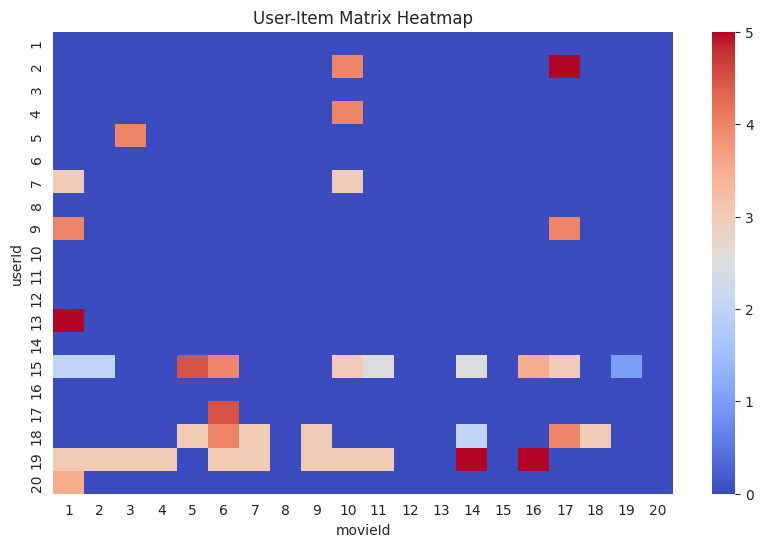

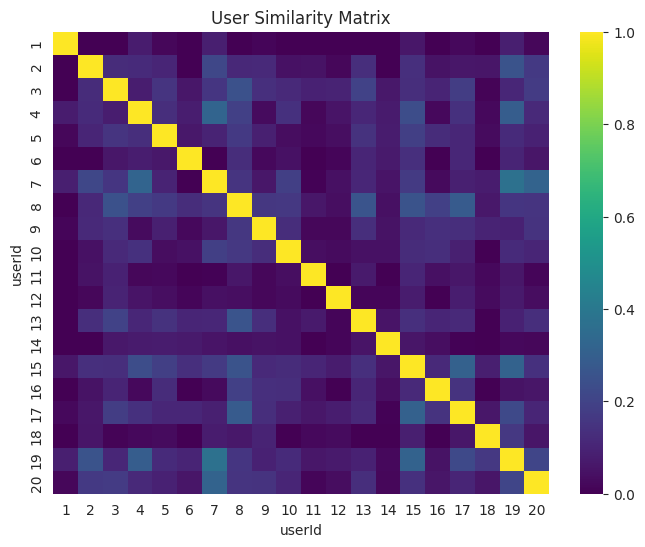

In [12]:
# User-Item Matrix Heatmap (sample)
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap='coolwarm')
plt.title("User-Item Matrix Heatmap")
plt.show()

# User Similarity Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("User Similarity Matrix")
plt.show()

# SCENARIO 2: ITEM-BASED COLLABORATIVE FILTERING

In [13]:
item_user_matrix = ratings.pivot_table(index='movieId', columns='userId', values='rating').fillna(0)

print(item_user_matrix.head())

userId   1    2    3    4    5    6    7    8    9    10   ...  662  663  664  \
movieId                                                    ...                  
1        0.0  0.0  0.0  0.0  0.0  0.0  3.0  0.0  4.0  0.0  ...  0.0  4.0  3.5   
2        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  5.0  0.0  0.0   
3        0.0  0.0  0.0  0.0  4.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
5        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

userId   665  666  667  668  669  670  671  
movieId                                     
1        0.0  0.0  0.0  0.0  0.0  4.0  5.0  
2        3.0  0.0  0.0  0.0  0.0  0.0  0.0  
3        3.0  0.0  0.0  0.0  0.0  0.0  0.0  
4        0.0  0.0  0.0  0.0  0.0  0.0  0.0  
5        3.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 671 columns]


In [14]:
item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix.index,
                                 columns=item_user_matrix.index)

In [15]:
def get_similar_items(movie_id, n=5):
    similar_items = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]
    return similar_items

print(get_similar_items(1))

movieId
3114    0.594710
260     0.576188
356     0.564534
780     0.562946
1265    0.548023
Name: 1, dtype: float64


In [16]:
def recommend_items(user_id, n=5):
    user_ratings = ratings[ratings['userId'] == user_id]
    
    similar_items = pd.Series(dtype=float)
    
    for movie in user_ratings['movieId']:
        similar = get_similar_items(movie, n)
        similar_items = pd.concat([similar_items, similar])
    
    similar_items = similar_items.groupby(similar_items.index).mean()
    return similar_items.sort_values(ascending=False).head(n)

print(recommend_items(1))

1375    0.642748
3152    0.618720
1022    0.617606
2143    0.599472
2078    0.579214
dtype: float64


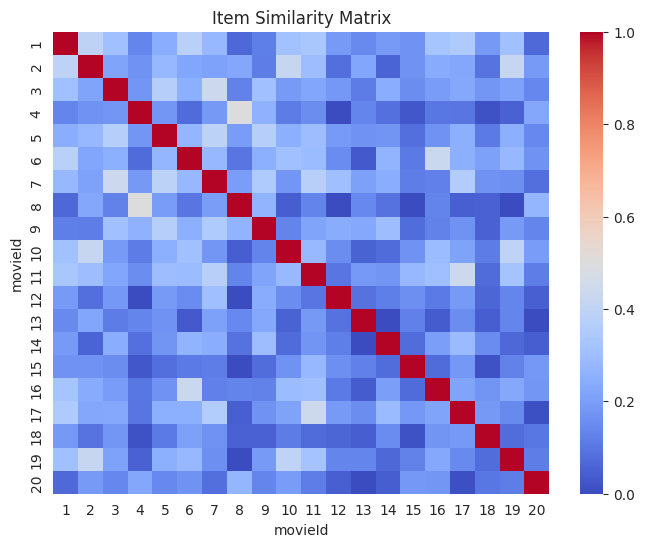

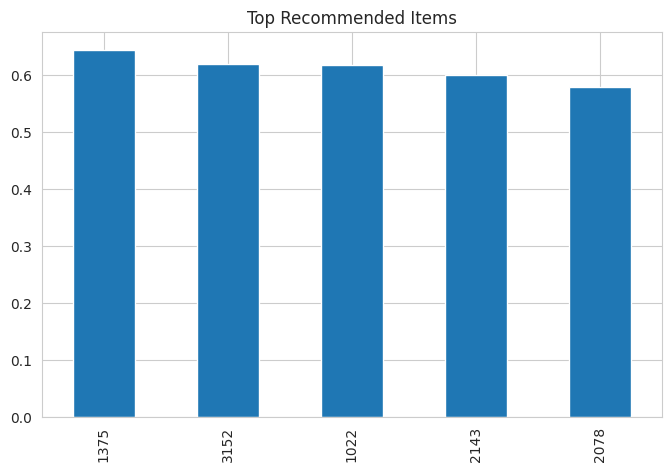

In [18]:
# Item similarity heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Matrix")
plt.show()

# Top recommended items visualization
top_items = recommend_items(1)

top_items.plot(kind='bar', figsize=(8,5))
plt.title("Top Recommended Items")
plt.show()